In [2]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

### Import Library

Pada tahap ini, kita mengimpor semua library yang dibutuhkan untuk menjalankan proyek pengolahan citra dan klasifikasi. Berikut penjelasan dari masing-masing library
os: Untuk interaksi dengan sistem file (misalnya membaca direktori).

cv2 (OpenCV): Digunakan untuk membaca, memproses, dan manipulasi gambar.

matplotlib.pyplot: Untuk menampilkan visualisasi gambar dan grafik.

numpy: Digunakan untuk operasi numerik dan manipulasi array.

pandas: Untuk memproses dan menganalisis data dalam bentuk tabel.

sklearn.model_selection: Untuk melakukan pembagian data dan validasi model.

sklearn.metrics: Untuk mengukur performa model (akurasi, precision, recall, dll).

skimage.feature: Untuk ekstraksi fitur dari gambar seperti GLCM (gray-level co-occurrence matrix).

scipy.stats: Untuk fungsi statistik seperti entropi.

sklearn.ensemble, svm, dan neighbors: Kumpulan algoritma klasifikasi seperti Random Forest, SVM, dan KNN.

seaborn: Untuk visualisasi data yang lebih interaktif dan menarik.

## Data Loading

In [3]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 300
Kelas: ['anggrek', 'lili', 'matahari']


In [4]:
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)

    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    return gray.astype(np.uint8)

def prepro(image):
    # Resize + Grayscale
    img = resize_grayscale(image)
    return img

### Fungsi Resize Gambar

Fungsi resize_grayscale menerima gambar, mengubah ukurannya ke 128x128 piksel menggunakan OpenCV, lalu mengonversinya ke skala abu-abu jika gambar masih berwarna (memiliki 3 kanal), dan mengembalikan hasil sebagai array uint8. Fungsi prepro adalah wrapper sederhana yang memanggil resize_grayscale dengan ukuran target default, sehingga setiap gambar yang masuk akan diubah menjadi citra grayscale berukuran 128x128

Fungsi percobaan1 hanya memanggil prepro untuk mengubah ukuran dan grayscale setiap gambar, lalu semua gambar diproses sekaligus melalui list comprehension menjadi dataPreprocessed. Selanjutnya, untuk setiap label unik dalam dataset, kode mengambil indeks gambar yang memiliki label tersebut, lalu membuat grid subplot berukuran 7 baris x 10 kolom (total 70 slot) untuk menampilkan hingga 70 contoh gambar dari kelas tersebut. Gambar ditampilkan dalam skala abu-abu (cmap='gray'), sumbu koordinat dimatikan agar tampilan rapi, dan slot kosong (jika jumlah gambar kurang dari 70) juga dinonaktifkan sumbunya. Hasilnya adalah serangkaian plot terpisah per kelas yang memudahkan inspeksi visual data latih setelah pra-pemrosesan.

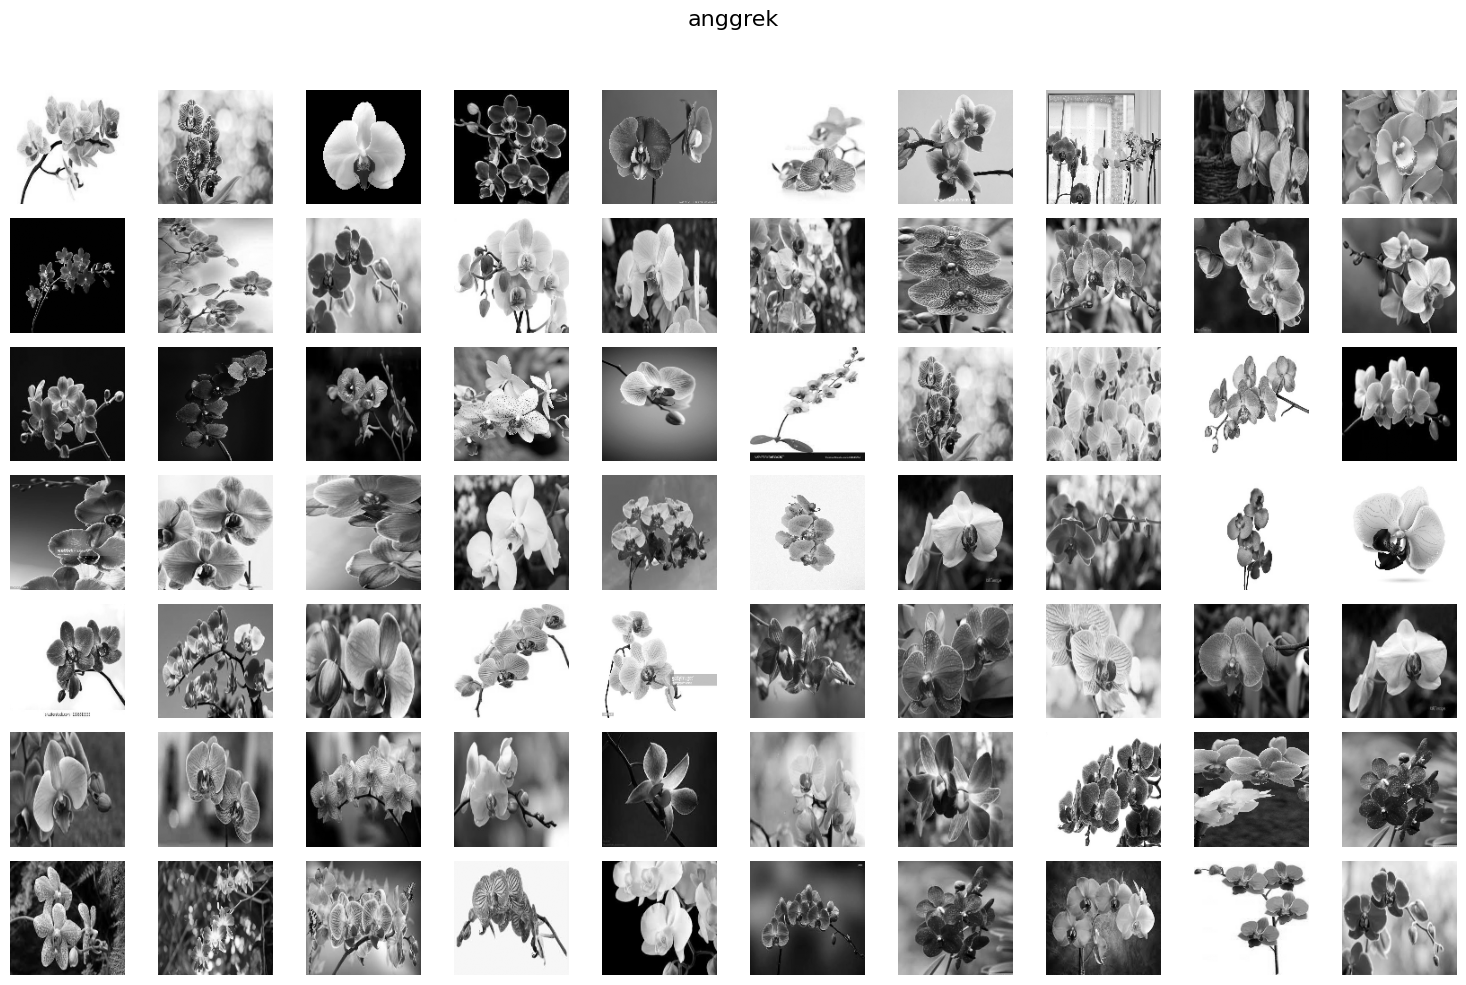

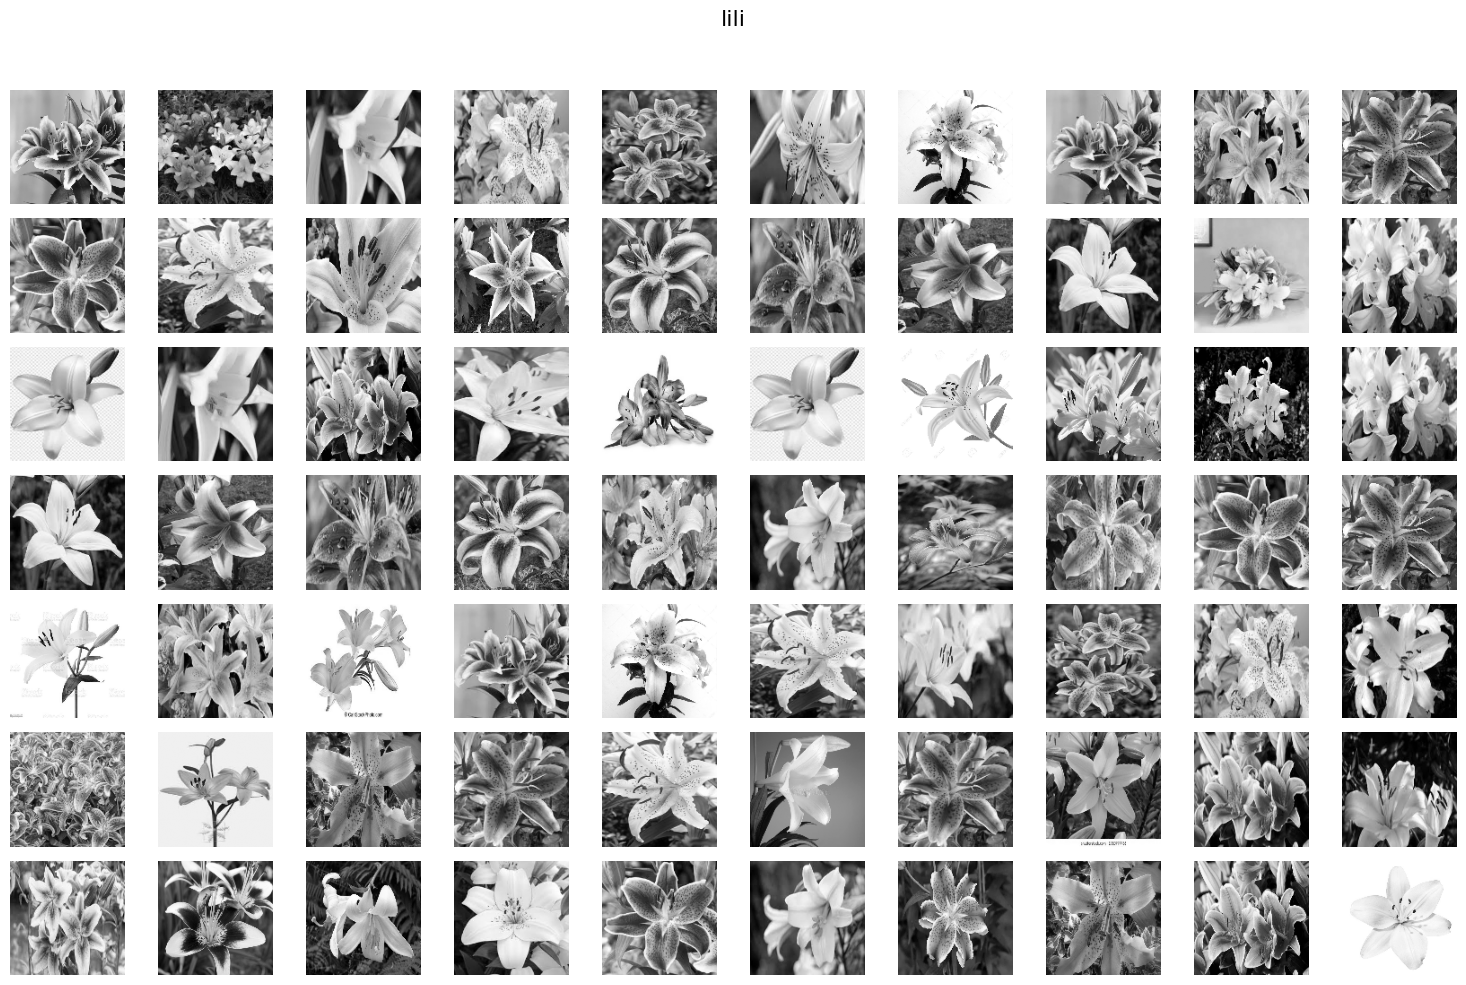

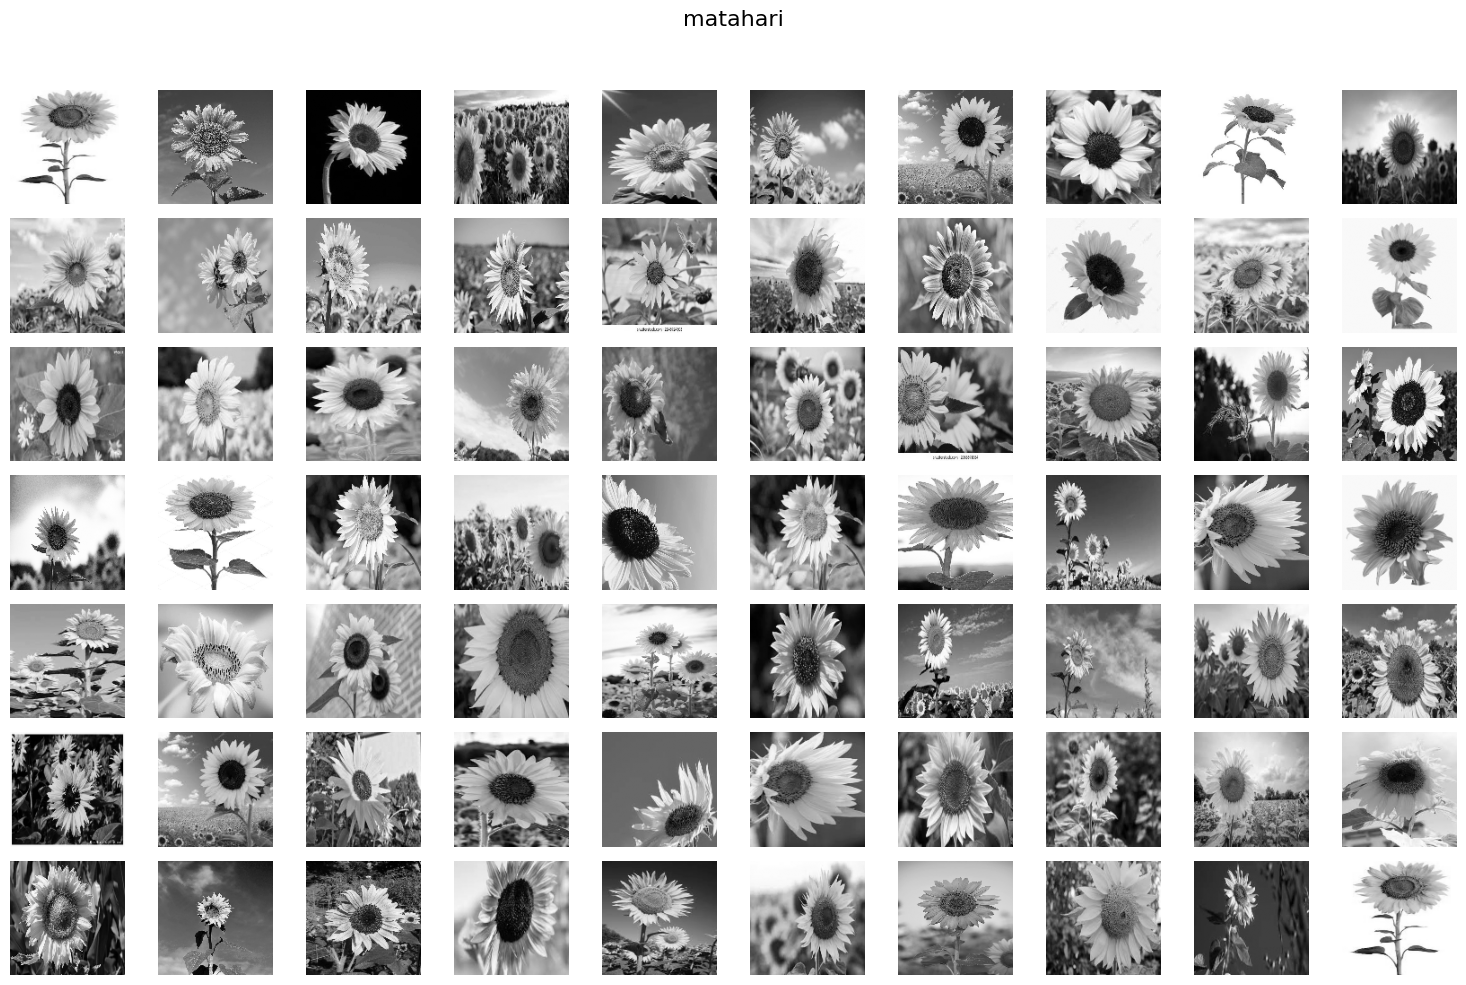

In [5]:
def percobaan1(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan1(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(7, 10, figsize=(15, 10)) 
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(70, len(idxs))):
        
        row = k // 10  
        col = k % 10   
        
        ax = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')
        
    for k in range(len(idxs), 70):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

### Feature Extraction

In [6]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

Kode di atas adalah fungsi `glcm(image, derajat)` yang digunakan untuk menghasilkan matriks GLCM (_Gray Level Co-occurrence Matrix_). Parameter `derajat` digunakan untuk menentukan arah perhitungan hubungan antar piksel: 0 derajat (horizontal), 45 derajat (diagonal kanan atas), 90 derajat (vertikal), atau 135 derajat (diagonal kiri atas). Jika `derajat` bernilai 0, maka sudut arah piksel diset menjadi 0 radian yang mewakili arah horizontal. Jika bernilai 45, maka arah piksel diatur menjadi π/4 radian yang menunjuk ke arah diagonal kanan atas. Untuk derajat 90, arah piksel diatur menjadi π/2 radian, sedangkan untuk 135 derajat, sudutnya menjadi 3π/4 radian. Apabila nilai derajat yang diberikan tidak termasuk ke dalam empat nilai yang valid, maka program akan menampilkan pesan _error_.
Setelah menentukan arah, fungsi akan memanggil `graycomatrix()` dari pustaka `skimage.feature`. Fungsi ini menghitung GLCM dari citra image dengan jarak antar piksel sebesar 1 piksel dan arah sesuai dengan `angles`. Parameter tambahan seperti 256 menunjukkan jumlah level keabuan dalam gambar (0 hingga 255),` symmetric=True` agar matriks simetris, dan `normed=True` agar hasilnya dinormalisasi.

### Ekstraksi Fitur: GLCM

Tahap ini menggunakan metode GLCM (Gray Level Co-occurrence Matrix) untuk mengambil fitur tekstur dari gambar.

#### Cara Kerja:
Fungsi menerima gambar grayscale dan sudut.

Sudut diubah ke radian agar bisa diproses oleh graycomatrix.

Hasilnya adalah matriks GLCM, yang digunakan untuk mengambil fitur seperti kontras, homogenitas, energi, dan lainnya.

In [7]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

##### Ekstraksi Fitur: Correlation

Tahap ini untuk mengambil nilai correlation dari matriks GLCM yang sudah dibuat sebelumnya.

Cara Kerja:
Fungsi menerima matriks GLCM hasil dari proses sebelumnya.

Menggunakan graycoprops untuk mengambil nilai correlation.

Nilai ini menunjukkan hubungan antar piksel di dalam gambar.

##### Ekstraksi Fitur: Dissimilarity

Tahap ini mengambil nilai dissimilarity dari matriks GLCM.

Cara Kerja:
Fungsi menerima matriks GLCM sebagai input.

Menggunakan graycoprops untuk mendapatkan nilai dissimilarity.

Nilai ini mengukur seberapa berbeda intensitas piksel yang berdekatan.

##### Ekstraksi Fitur: Homogeneity
Tahap ini mengambil nilai homogeneity dari matriks GLCM.

Cara Kerja:
Fungsi menerima matriks GLCM sebagai input.

Menggunakan graycoprops untuk mendapatkan nilai homogeneity.

Nilai ini mengukur seberapa mirip intensitas piksel yang berdekatan.

##### Fungsi Ekstraksi Fitur: Contrast

Fungsi ini menerima sebuah matriks GLCM sebagai input.
Lalu, fungsi memanggil graycoprops dengan parameter 'contrast' untuk menghitung nilai kontras dari tekstur gambar tersebut.

Nilai contrast menunjukkan seberapa besar variasi intensitas piksel di gambar.
Semakin tinggi nilainya, semakin besar perbedaan intensitas antar piksel di gambar.

##### Fungsi ASM (Angular Second Moment)
Fungsi ini menghitung nilai ASM dari matriks GLCM.

Cara Kerja:
Fungsi memanggil graycoprops dengan parameter 'ASM' untuk mendapatkan nilai Angular Second Moment.

Nilai ASM menunjukkan tingkat keteraturan atau homogenitas tekstur pada gambar.
Semakin tinggi nilainya, berarti tekstur gambar semakin seragam dan teratur.

##### Fungsi Energy
Fungsi ini menghitung nilai Energy dari matriks GLCM.

Cara Kerja:
Fungsi memanggil graycoprops dengan parameter 'energy' untuk mendapatkan nilai energy tekstur pada gambar.

Nilai Energy menunjukkan kekuatan atau intensitas tekstur.
Semakin tinggi nilainya, berarti tekstur gambar lebih kuat dan teratur.

##### Fungsi Entropy pada GLCM
Fungsi ini menghitung nilai Entropy dari matriks GLCM.

Nilai Entropy menunjukkan seberapa acak atau kompleks tekstur pada gambar.
Semakin tinggi nilai Entropy, semakin kompleks teksturnya.
Fitur ini membantu membedakan jenis tekstur dalam analisis citra.

In [8]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 300 citra.


##### Ekstraksi Fitur GLCM pada Beberapa Sudut
Kode ini menghitung matriks GLCM dari setiap gambar hasil median filter (dataPreprocessed) pada 4 sudut berbeda: 0°, 45°, 90°, dan 135°.

Cara Kerja:

Untuk setiap gambar, fungsi glcm dipanggil dengan sudut 0, 45, 90, dan 135 derajat.

Hasil matriks GLCM untuk masing-masing sudut disimpan ke dalam list terpisah (Derajat0, Derajat45, Derajat90, dan Derajat135).

Kenapa Dilakukan?
Mengambil GLCM dari beberapa sudut bertujuan agar fitur tekstur yang diambil lebih lengkap dan akurat, karena tekstur bisa berbeda tergantung arah pengamatan.

##### Inisialisasi List untuk Menyimpan Fitur GLCM
Kode ini membuat beberapa list kosong untuk menyimpan nilai fitur tekstur dari matriks GLCM pada setiap sudut (0°, 45°, 90°, 135°).

List yang dibuat meliputi:

Kontras (contrast)

Dissimilarity

Homogenitas (homogeneity)

Entropy

ASM (Angular Second Moment)

Energi (energy)

Korelasi (correlation)

Setiap list disiapkan untuk keempat sudut, sehingga hasil ekstraksi fitur nantinya dapat dipisahkan berdasarkan arah sudut GLCM.

##### Fitur tekstur GLCM 

(Gray-Level Co-occurrence Matrix) dari setiap gambar yang telah diproses sebelumnya, dengan menghitung 7 fitur statistik (kontras, dissimilarity, homogenitas, entropi, ASM, energi, dan korelasi) untuk 4 orientasi sudut yang berbeda yaitu 0°, 45°, 90°, dan 135°. Untuk setiap gambar ke-i dalam dataPreprocessed, kode mengambil matriks GLCM dari empat versi derajat sudut gambar tersebut (Derajat0[i] hingga Derajat135[i]), lalu menghitung nilai fitur menggunakan fungsi-fungsi seperti contrast(), dissimilarity(), homogenity(), entropyGlcm(), ASM(), energy(), dan correlation_feat(). Hasil perhitungan untuk setiap sudut disimpan ke dalam list terpisah (misalnya Kontras0, Kontras45, dst.) sehingga nantinya tersedia 28 vektor fitur (7 fitur × 4 sudut) untuk setiap gambar. Setelah seluruh gambar diproses, kode mencetak pesan konfirmasi bahwa ekstraksi fitur telah selesai untuk semua citra.

### Write the extraction's results to CSV

##### Menyimpan dan Menyiapkan Data Fitur
Kode ini membuat tabel data fitur hasil ekstraksi, menyimpannya dalam file CSV, lalu memuat kembali data untuk analisis.

Langkah-langkah:

Membuat dictionary dataTable yang berisi nama file, kelas, dan semua fitur tekstur dari berbagai sudut.

Mengubah dictionary menjadi DataFrame pandas.

Menyimpan DataFrame ke file CSV bernama hasil_ekstraksi_pros2.csv.

Membaca kembali data dari file CSV.

In [18]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,anggrek_1.jpg,anggrek,653.898930,1000.760804,448.664124,740.343543,0.520559,0.501060,0.533709,0.498656,...,0.172028,0.159306,0.411280,0.399351,0.414762,0.399131,0.886288,0.826642,0.921919,0.871753
1,anggrek_2.jpg,anggrek,859.809486,985.691797,663.426366,899.793974,0.190241,0.158557,0.242639,0.169698,...,0.000534,0.000359,0.020792,0.018522,0.023110,0.018945,0.867877,0.848108,0.897638,0.861347
2,anggrek_3.jpg,anggrek,681.689222,888.607849,507.359744,837.643251,0.706178,0.681176,0.713307,0.687241,...,0.367560,0.359911,0.604785,0.599486,0.606267,0.599926,0.963491,0.952573,0.972828,0.955293
3,anggrek_4.jpg,anggrek,818.165108,1115.929630,753.516179,1281.628061,0.444486,0.413409,0.442461,0.411520,...,0.097706,0.090785,0.310873,0.301839,0.312580,0.301305,0.835204,0.775850,0.848277,0.742564
4,anggrek_5.jpg,anggrek,322.380906,375.976750,161.525406,348.535557,0.544944,0.538165,0.612052,0.528815,...,0.009964,0.007245,0.088293,0.087270,0.099818,0.085118,0.788206,0.754621,0.894016,0.772531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,matahari_96.jpg,matahari,136.353839,231.367475,168.357160,283.621055,0.645089,0.629435,0.656469,0.623886,...,0.312867,0.303209,0.559875,0.551447,0.559345,0.550644,0.976072,0.959606,0.970461,0.950484
296,matahari_97.jpg,matahari,416.266363,537.725153,242.556779,544.692169,0.153766,0.133380,0.203289,0.138213,...,0.000355,0.000249,0.016612,0.015602,0.018839,0.015782,0.933899,0.914679,0.961346,0.913573
297,matahari_98.jpg,matahari,323.011073,398.287061,144.233022,390.461343,0.168728,0.140545,0.227752,0.147751,...,0.000414,0.000265,0.017057,0.015797,0.020344,0.016289,0.910163,0.889749,0.959924,0.891918
298,matahari_99.jpg,matahari,228.673536,327.132432,140.625615,269.574989,0.232124,0.191740,0.264018,0.190418,...,0.001129,0.000878,0.032741,0.029669,0.033604,0.029626,0.960158,0.943107,0.975664,0.953116


### Features Selection

### Fitur berbasis korelasi (Correlation-based Feature Selection)

Untuk mengurangi redundansi antar fitur. Pertama, dari `hasilEkstrak` yang berisi 28 fitur tekstur, kode menghitung matriks korelasi dengan mengabaikan kolom 'Label' dan 'Filename'. Kemudian dengan ambang batas `threshold = 0.95`, kode melakukan iterasi pada matriks korelasi dan menandai kolom mana yang memiliki korelasi absolut ≥ 0.95 dengan kolom lain; jika ditemukan, kolom yang kedua (indeks `j`) akan dihapus dengan menandainya `False` sehingga hanya satu dari pasangan fitur yang sangat berkorelasi tinggi yang dipertahankan. Setelah seleksi, kode membentuk dataset baru `x_new` yang hanya berisi fitur-fitur terpilih, sementara `y` tetap berisi label kelas. Kode kemudian mencetak jumlah fitur sebelum (28) dan sesudah seleksi beserta daftar fitur yang terpilih, serta menampilkan heatmap korelasi dari fitur-fitur terpilih tersebut menggunakan `sns.heatmap` untuk memverifikasi bahwa fitur yang tersisa sudah tidak memiliki korelasi yang sangat tinggi satu sama lain.

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 10
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity90', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90']


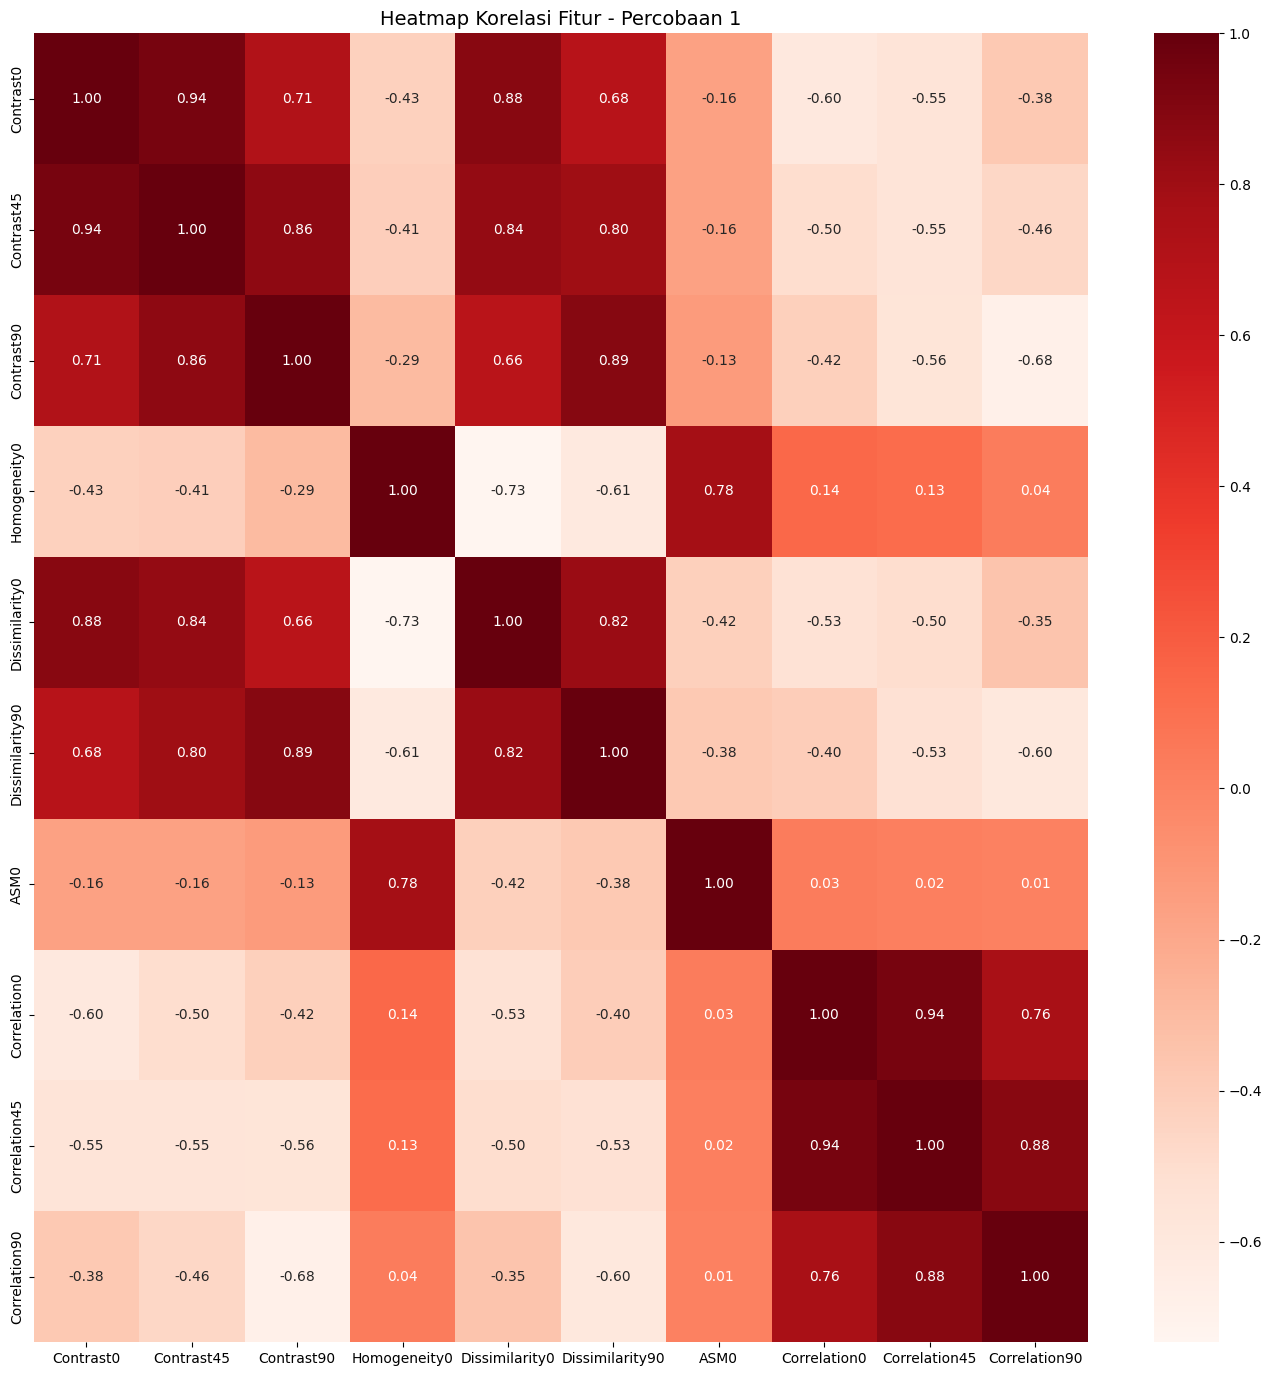

In [27]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Reds', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 1', fontsize=14)
plt.show()

## Splitting Data

##### Membagi Data: Train dan Test

Kode ini membagi dataset hasil seleksi fitur menjadi data latih dan data uji menggunakan fungsi `train_test_split` dari scikit-learn. Dari `x_new` (fitur-fitur terpilih) dan `y` (label kelas), kode mengalokasikan 20% data sebagai data uji (`test_size=0.2`) dan 80% sisanya sebagai data latih, dengan `random_state=42` untuk memastikan hasil pembagian dapat direproduksi. Hasilnya disimpan dalam empat variabel: `X_train` dan `y_train` untuk fitur dan label data latih, serta `X_test` dan `y_test` untuk fitur dan label data uji. Dua baris `print` berikutnya menampilkan dimensi (jumlah sampel × jumlah fitur) dari `X_train` dan `X_test`, yang memungkinkan pengecekan jumlah data latih dan uji sesuai proporsi yang diharapkan (misalnya jika total data 100, maka X_train berukuran 80×jumlah_fitur dan X_test 20×jumlah_fitur).

In [28]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(240, 10)
(60, 10)


## Feature Normalization

Kode menghitung nilai rata-rata (mean_train) dan standar deviasi (std_train) dari setiap fitur di X_train. Kemudian, kedua dataset (X_train dan X_test) distandarisasi dengan rumus (nilai - mean) / std menggunakan mean dan std dari data latih. Penting untuk dicatat bahwa data uji distandarisasi dengan parameter data latih (bukan mean/std-nya sendiri) untuk menghindari kebocoran data (data leakage) dan memastikan bahwa model dievaluasi pada skala yang konsisten dengan data yang digunakan saat pelatihan. Hasilnya, semua fitur kini memiliki rata-rata 0 dan standar deviasi 1 (untuk data latih), sementara data uji disesuaikan dengan skala yang sama tanpa menggunakan informasinya sendiri.

In [29]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Modeling

### Define Model

In [30]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

##### Definisi Model dan Evaluasi Klasifikasi
Kode ini mendefinisikan fungsi untuk mengevaluasi hasil prediksi dan juga membuat beberapa model klasifikasi yang akan digunakan.

Fungsi generateClassificationReport
Menerima data asli (y_true) dan hasil prediksi (y_pred).

Menampilkan laporan klasifikasi lengkap (precision, recall, f1-score).

Menampilkan confusion matrix untuk melihat detail kesalahan prediksi.

Menampilkan akurasi sebagai ukuran kinerja model.

Model yang Didefinisikan:
Random Forest (rf): Model ensemble dengan 5 pohon keputusan.

SVM (svm): Support Vector Machine dengan kernel RBF.

KNN (knn): K-Nearest Neighbors dengan jumlah tetangga 5.

### Train Random Forest Classifier

In [31]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     anggrek       0.91      0.94      0.92        78
        lili       0.94      0.99      0.97        84
    matahari       0.96      0.88      0.92        78

    accuracy                           0.94       240
   macro avg       0.94      0.94      0.94       240
weighted avg       0.94      0.94      0.94       240

[[73  2  3]
 [ 1 83  0]
 [ 6  3 69]]
Accuracy: 0.9375

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.62      0.73      0.67        22
        lili       0.58      0.69      0.63        16
    matahari       0.80      0.55      0.65        22

    accuracy                           0.65        60
   macro avg       0.66      0.65      0.65        60
weighted avg       0.67      0.65      0.65        60

[[16  4  2]
 [ 4 11  1]
 [ 6  4 12]]
Accuracy: 0.65


### Train SVM Classifier

In [35]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.58      0.68      0.63        78
        lili       0.74      0.69      0.72        84
    matahari       0.70      0.64      0.67        78

    accuracy                           0.67       240
   macro avg       0.68      0.67      0.67       240
weighted avg       0.68      0.67      0.67       240

[[53 12 13]
 [18 58  8]
 [20  8 50]]
Accuracy: 0.6708333333333333

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.65      0.59      0.62        22
        lili       0.52      0.75      0.62        16
    matahari       0.65      0.50      0.56        22

    accuracy                           0.60        60
   macro avg       0.61      0.61      0.60        60
weighted avg       0.61      0.60      0.60        60

[[13  5  4]
 [ 2 12  2]
 [ 5  6 11]]
Accuracy: 0.6


### Train KNN Classifier

In [32]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.58      0.69      0.63        78
        lili       0.77      0.77      0.77        84
    matahari       0.73      0.59      0.65        78

    accuracy                           0.69       240
   macro avg       0.69      0.69      0.69       240
weighted avg       0.70      0.69      0.69       240

[[54  9 15]
 [17 65  2]
 [22 10 46]]
Accuracy: 0.6875

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.56      0.41      0.47        22
        lili       0.43      0.75      0.55        16
    matahari       0.56      0.41      0.47        22

    accuracy                           0.50        60
   macro avg       0.52      0.52      0.50        60
weighted avg       0.53      0.50      0.49        60

[[ 9  8  5]
 [ 2 12  2]
 [ 5  8  9]]
Accuracy: 0.5


## Evaluation With Confusion Matrix

Fungsi `plot_confusion_matrix` untuk memvisualisasikan kinerja klasifikasi tiga model (Random Forest, SVM, dan KNN) menggunakan confusion matrix. Fungsi tersebut menerima label asli (`y_true`), prediksi model (`y_pred`), dan judul, lalu menghitung confusion matrix dengan `confusion_matrix`, menampilkannya menggunakan `ConfusionMatrixDisplay` dengan label kelas 'Anggrek', 'Lili', dan 'Bunga Matahari', serta menggunakan colormap merah (`cmap=plt.cm.Reds`) dan format angka integer.

Untuk Random Forest, kode langsung memprediksi `X_test` menggunakan model `rf` yang sudah dilatih sebelumnya. Untuk SVM, kode membuat instance SVC dengan kernel RBF, `C=1.0`, lalu melatihnya dengan `X_train` dan `y_train` sebelum memprediksi. Untuk KNN, kode memprediksi menggunakan model `knn` yang sudah ada (meskipun tidak terlihat inisialisasi dan pelatihannya di potongan kode ini, diasumsikan sudah didefinisikan sebelumnya). Ketiga confusion matrix ditampilkan secara bergantian dengan judul masing-masing, memungkinkan perbandingan visual kinerja ketiga algoritma dalam mengklasifikasikan tiga jenis bunga.

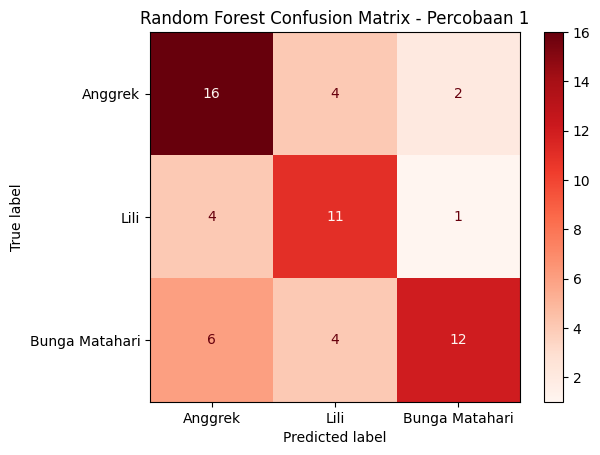

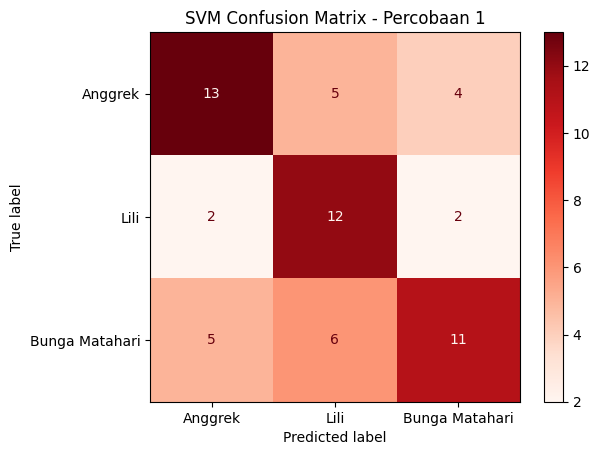

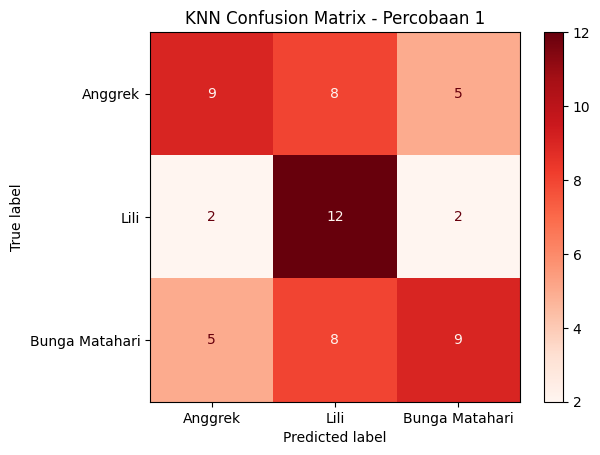

In [33]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Anggrek', 'Lili', 'Bunga Matahari']
    )

    disp.plot(cmap=plt.cm.Reds, values_format='d')
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(
    y_test,
    rf.predict(X_test),
    "Random Forest Confusion Matrix - Percobaan 1"
)

# Plot confusion matrix for SVM
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=1.0, random_state=42)
svm.fit(X_train, y_train)

plot_confusion_matrix(
    y_test,
    svm.predict(X_test),
    "SVM Confusion Matrix - Percobaan 1"
)

# Plot confusion matrix for KNN
plot_confusion_matrix(
    y_test,
    knn.predict(X_test),
    "KNN Confusion Matrix - Percobaan 1"
)

Kode ini membuat ringkasan perbandingan kinerja tiga model klasifikasi (Random Forest, SVM, dan KNN) dalam bentuk tabel dan menyimpannya ke file CSV. Dictionary `hasil_klasifikasi` berisi enam metrik evaluasi: akurasi data latih, akurasi data uji, presisi (weighted average), recall (weighted average), dan F1-score (weighted average) untuk setiap model. Untuk Random Forest dan KNN, kode menggunakan model yang sudah dilatih sebelumnya (`rf` dan `knn`), sedangkan untuk SVM menggunakan model `svm` yang baru saja dilatih pada potongan kode sebelumnya. Metrik `weighted average` digunakan untuk menangani ketidakseimbangan kelas dengan memberi bobot berdasarkan jumlah sampel per kelas, dan `zero_division=0` mencegah pembagian dengan nol jika ada kelas yang tidak terprediksi. Setelah dictionary dikonversi menjadi DataFrame menggunakan pandas, hasilnya disimpan sebagai file CSV bernama `hasil_klasifikasi_pros1.csv` tanpa indeks, lalu mencetak pesan konfirmasi dan menampilkan tabel ringkasan tersebut.

In [34]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('hasil_klasifikasi_pros1.csv', index=False)
print("✅ File hasil_klasifikasi_Percobaan1.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi_Percobaan1.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.937500,0.65,0.673360,0.65,0.649901
1,SVM,0.670833,0.60,0.614719,0.60,0.597924
2,KNN,0.687500,0.50,0.526786,0.50,0.492823
